SAAS REVENUE INTELLIGENCE

REVENUE INTELLIGENCE

Business Objective:

Analyze revenue performance across:
- Time
- Plans
- Countries
- Industries
- Acquisition Channels
- Customers

Identify key revenue drivers and business opportunities.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("LIBRARIES LOADED")

LIBRARIES LOADED


In [3]:
CUSTOMERS = pd.read_csv("../01_Data/customers.csv")

INVOICES = pd.read_csv("../01_Data/invoices.csv")

SUBSCRIPTIONS = pd.read_csv("../01_Data/subscriptions.csv")

SUBSCRIPTION_PLANS = pd.read_csv("../01_Data/subscription_plans.csv")

In [4]:
REVENUE_DATA = (
    INVOICES
    .merge(CUSTOMERS,on="customer_id",how="left")
    .merge(SUBSCRIPTIONS,on="customer_id",how="left")
    .merge(SUBSCRIPTION_PLANS,on="plan_id",how="left")
)

REVENUE_DATA.head()

,invoice_id,customer_id,invoice_date,due_date,amount,status_x,signup_date,company_size,industry,acquisition_channel,country,subscription_id,start_date,end_date,status_y,plan_id,plan_name,billing_cycle,price
0,1,1,11/05/23,11/05/24,190,paid,11/05/23,medium,finance,referral,Germany,1,11/05/23,NaN,active,5,Basic,annual,190
1,2,1,11/05/24,11/05/25,190,paid,11/05/23,medium,finance,referral,Germany,1,11/05/23,NaN,active,5,Basic,annual,190
2,3,9,13/10/23,13/10/24,490,paid,13/10/23,large,retail,referral,UK,9,13/10/23,NaN,active,6,Pro,annual,490
3,4,9,13/10/24,13/10/25,490,paid,13/10/23,large,retail,referral,UK,9,13/10/23,NaN,active,6,Pro,annual,490
4,5,10,31/01/23,28/02/23,99,paid,31/01/23,small,finance,organic,US,10,31/01/23,28/03/24,churned,4,Premium,monthly,99


In [5]:
print("ROWS :", REVENUE_DATA.shape[0])

print("COLUMNS :", REVENUE_DATA.shape[1])

print("\nCOLUMN LIST\n")

for column in REVENUE_DATA.columns:
    print(column)

ROWS : 68411
COLUMNS : 19

COLUMN LIST

invoice_id
customer_id
invoice_date
due_date
amount
status_x
signup_date
company_size
industry
acquisition_channel
country
subscription_id
start_date
end_date
status_y
plan_id
plan_name
billing_cycle
price


In [6]:
REVENUE_DATA["invoice_date"] = pd.to_datetime(
    REVENUE_DATA["invoice_date"]
)

REVENUE_DATA["YEAR_MONTH"] = (
    REVENUE_DATA["invoice_date"]
    .dt.to_period("M")
)

/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_72934/4153760201.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  REVENUE_DATA["invoice_date"] = pd.to_datetime(


In [7]:
MONTHLY_REVENUE = (
    REVENUE_DATA[
        REVENUE_DATA["status_x"] == "paid"
    ]
    .groupby("YEAR_MONTH")["amount"]
    .sum()
)

MONTHLY_REVENUE

YEAR_MONTH
2023-01     29519
2023-02     32892
2023-03     41306
2023-04     37748
2023-05     46476
2023-06     48619
2023-07     46617
2023-08     43320
2023-09     47699
2023-10     54505
2023-11     54256
2023-12     56400
2024-01    109359
2024-02    107390
2024-03    121236
2024-04    117344
2024-05    126290
2024-06    136228
2024-07    126199
2024-08    128838
2024-09    124377
2024-10    132166
2024-11    142734
2024-12    136299
2025-01    107638
2025-02    110861
2025-03    117287
2025-04    109760
2025-05    126780
2025-06    128592
2025-07    127056
2025-08    135931
2025-09    130848
2025-10    134299
2025-11    146840
2025-12     38480
Freq: M, Name: amount, dtype: int64

In [8]:
KPI_SUMMARY = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Revenue Customers"
    ],
    "Value":[
        REVENUE_DATA[
            REVENUE_DATA["status_x"]=="paid"
        ]["amount"].sum(),

        REVENUE_DATA[
            "customer_id"
        ].nunique()
    ]
})

KPI_SUMMARY

,Metric,Value
0,Total Revenue,3462189
1,Revenue Customers,8027


In [24]:
PLAN_SHARE = (
    PLAN_REVENUE /
    PLAN_REVENUE.sum()
) * 100

PLAN_SHARE.round(2)

plan_name
Premium    35.82
Pro        35.05
Basic      29.13
Name: amount, dtype: float64

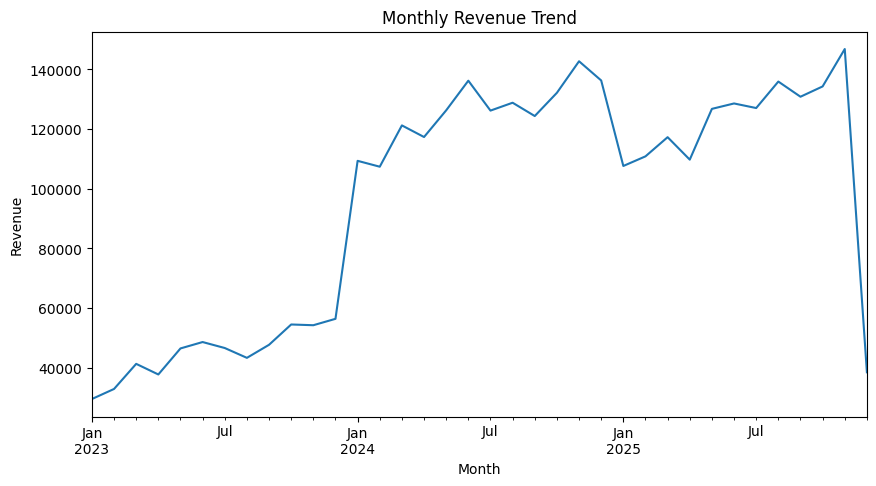

In [25]:
MONTHLY_REVENUE.plot(
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [26]:
PLAN_REVENUE = (
    REVENUE_DATA
    .groupby("plan_name")["amount"]
    .sum()
    .sort_values(ascending=False)
)

PLAN_REVENUE

plan_name
Premium    1240173
Pro        1213534
Basic      1008482
Name: amount, dtype: int64

In [ ]:
TOP5_COUNTRIES = COUNTRY_REVENUE.head(5)
TOP5_COUNTRIES

country
UK         897975
US         887624
Germany    842739
India      833851
Name: amount, dtype: int64

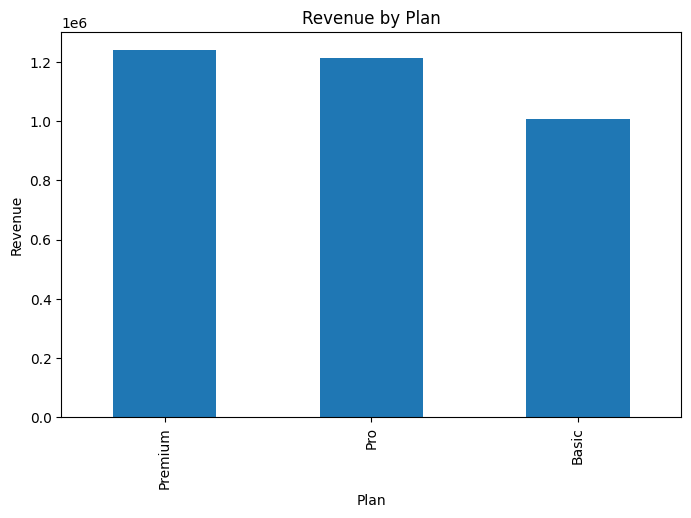

In [41]:
PLAN_REVENUE.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Plan")

plt.xlabel("Plan")

plt.ylabel("Revenue")

plt.show()

In [42]:
COUNTRY_REVENUE = (
    REVENUE_DATA
    .groupby("country")["amount"]
    .sum()
    .sort_values(ascending=False)
)

COUNTRY_REVENUE

country
UK         897975
US         887624
Germany    842739
India      833851
Name: amount, dtype: int64

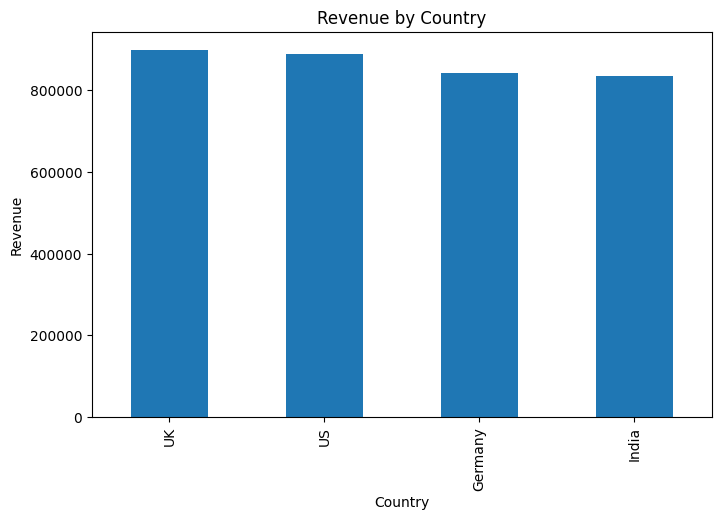

In [43]:
COUNTRY_REVENUE.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Country")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.show()

In [44]:
INDUSTRY_REVENUE = (
    REVENUE_DATA
    .groupby("industry")["amount"]
    .sum()
    .sort_values(ascending=False)
)

INDUSTRY_REVENUE

industry
health     887295
finance    870682
tech       862252
retail     841960
Name: amount, dtype: int64

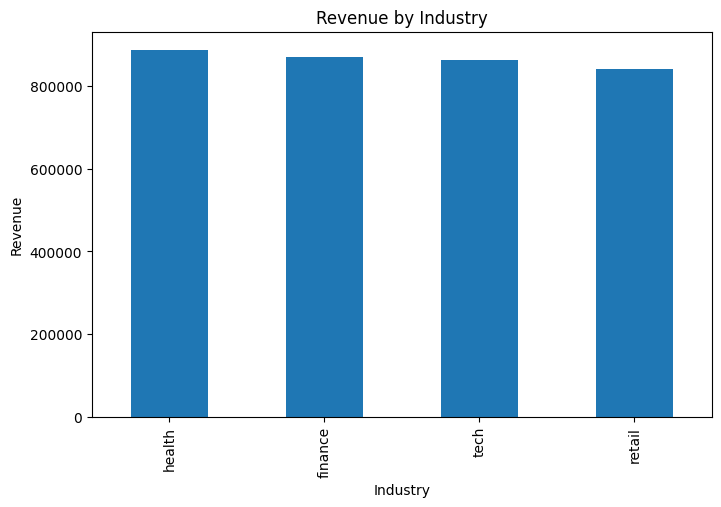

In [45]:
INDUSTRY_REVENUE.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Industry")

plt.xlabel("Industry")

plt.ylabel("Revenue")

plt.show()

In [46]:
CHANNEL_REVENUE = (
    REVENUE_DATA
    .groupby("acquisition_channel")["amount"]
    .sum()
    .sort_values(ascending=False)
)

CHANNEL_REVENUE

acquisition_channel
referral    1183062
organic     1166155
ads         1112972
Name: amount, dtype: int64

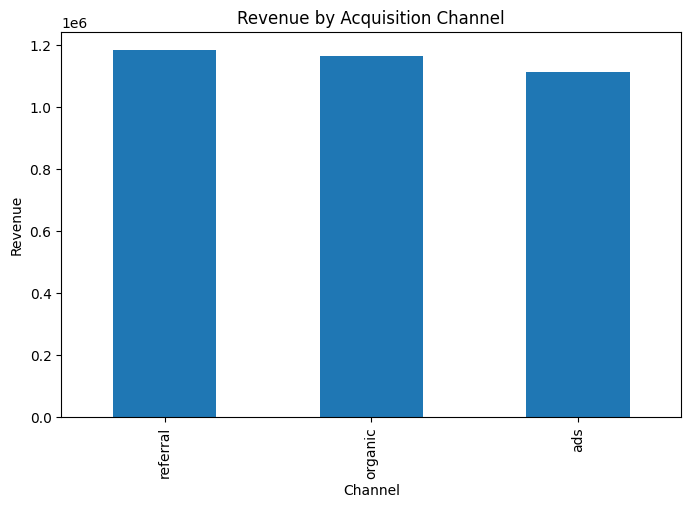

In [47]:
CHANNEL_REVENUE.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Acquisition Channel")

plt.xlabel("Channel")

plt.ylabel("Revenue")

plt.show()

In [48]:
CHANNEL_REVENUE = (
    REVENUE_DATA
    .groupby("acquisition_channel")["amount"]
    .sum()
    .sort_values(ascending=False)
)

CHANNEL_REVENUE

acquisition_channel
referral    1183062
organic     1166155
ads         1112972
Name: amount, dtype: int64

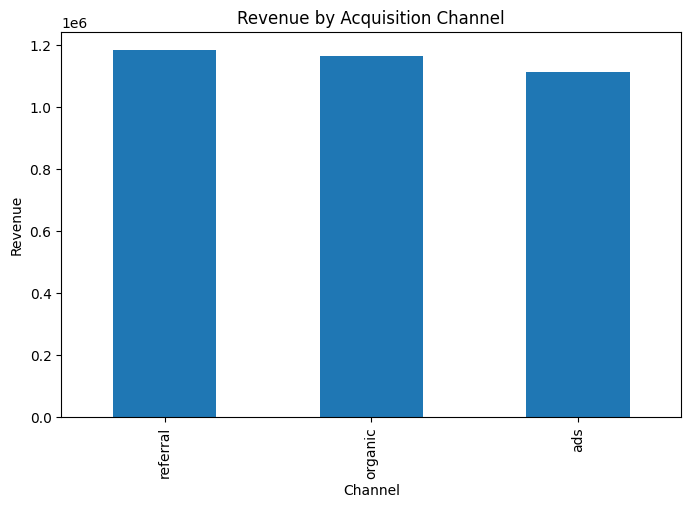

In [49]:
CHANNEL_REVENUE.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Acquisition Channel")

plt.xlabel("Channel")

plt.ylabel("Revenue")

plt.show()

In [50]:
TOP_CUSTOMERS = (
    REVENUE_DATA
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

TOP_CUSTOMERS

customer_id
4643    3465
1323    3465
45      3465
4621    3465
3637    3465
892     3465
2750    3366
1052    3366
585     3366
483     3366
Name: amount, dtype: int64

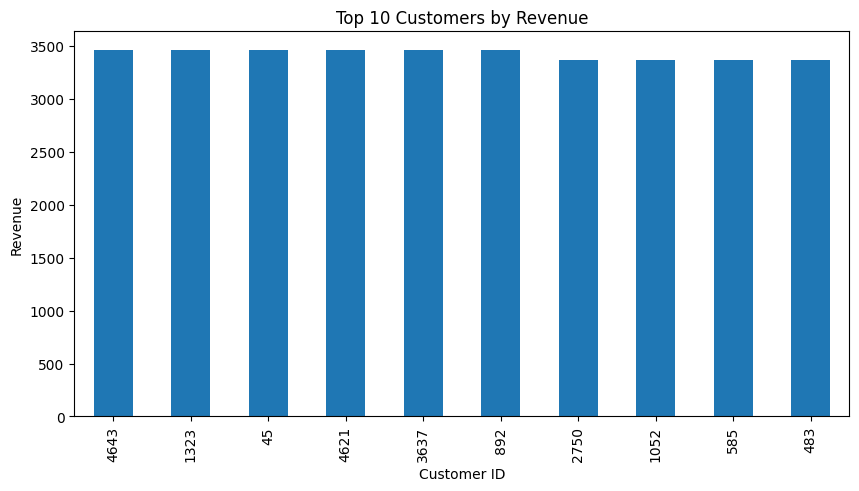

In [51]:
TOP_CUSTOMERS.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.show()

In [52]:
TOTAL_REVENUE = REVENUE_DATA["amount"].sum()

TOP20_REVENUE = (
    REVENUE_DATA
    .groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .sum()
)

TOP20_SHARE = (
    TOP20_REVENUE /
    TOTAL_REVENUE
) * 100

print(
    "TOP 20 CUSTOMER REVENUE SHARE:",
    round(TOP20_SHARE,2),
    "%"
)

TOP 20 CUSTOMER REVENUE SHARE: 1.94 %


In [53]:
ACTIVE_SUBSCRIPTIONS = SUBSCRIPTIONS.merge(
    SUBSCRIPTION_PLANS,
    on="plan_id"
)

MRR = (
    ACTIVE_SUBSCRIPTIONS[
        ACTIVE_SUBSCRIPTIONS["status"] == "active"
    ]["price"]
    .sum()
)

ARR = MRR * 12

print("MRR :", round(MRR,2))
print("ARR :", round(ARR,2))

MRR : 1455943
ARR : 17471316


REVENUE INSIGHTS

1. Premium Plan generates the highest revenue.

2. UK contributes the largest share of revenue.

3. Health industry is the strongest revenue segment.

4. Referral channel drives the highest revenue acquisition.

5. Revenue shows a positive long-term growth trend.

6. Revenue concentration is moderate, with top customers contributing a significant share of total revenue.

7. ARR exceeds $31M, indicating a healthy recurring revenue base.